In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/sivapriyaseelamreddy/dataset-sales/advertising.csv


In [2]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/sivapriyaseelamreddy/dataset-sales/advertising.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [6]:
df.shape

(200, 4)

In [7]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [9]:
df.dtypes

TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

In [10]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [3]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

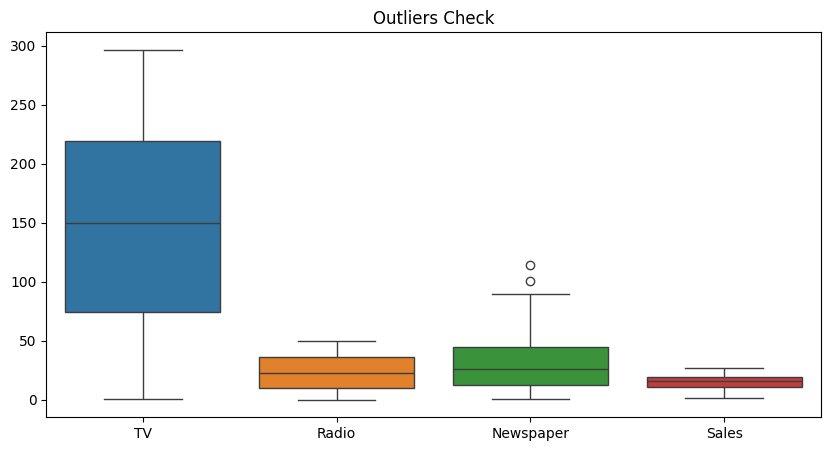

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.boxplot(data=df)

plt.title("Outliers Check")
plt.show()

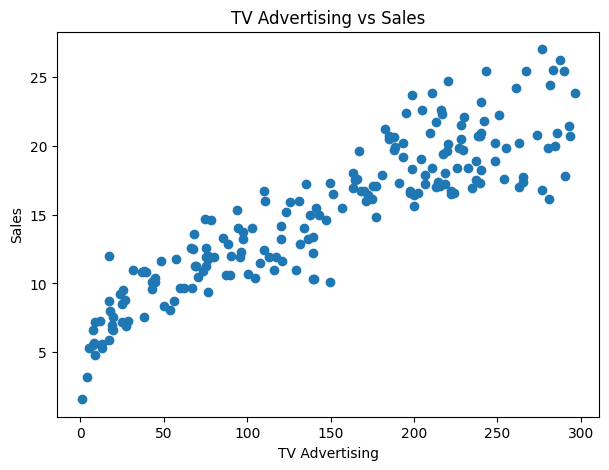

In [6]:
plt.figure(figsize=(7, 5))

plt.scatter(df["TV"], df["Sales"])

plt.xlabel("TV Advertising")
plt.ylabel("Sales")
plt.title("TV Advertising vs Sales")

plt.show()

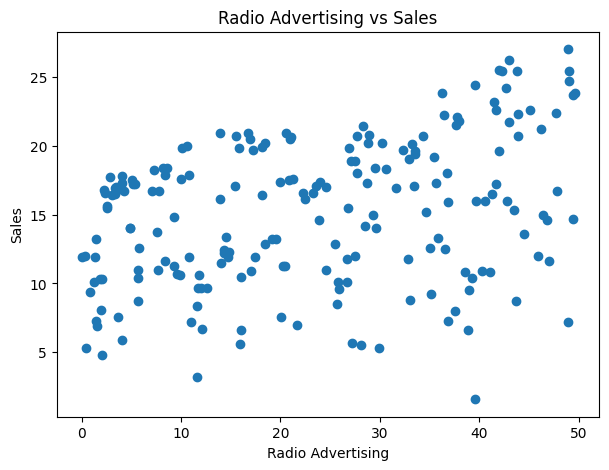

In [7]:
plt.figure(figsize=(7, 5))

plt.scatter(df["Radio"], df["Sales"])

plt.xlabel("Radio Advertising")
plt.ylabel("Sales")
plt.title("Radio Advertising vs Sales")

plt.show()

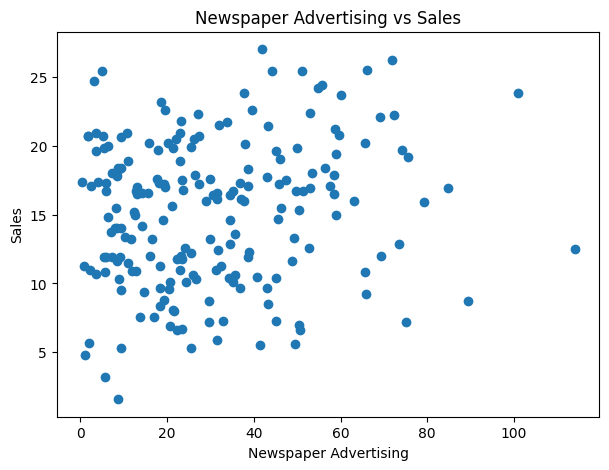

In [8]:
plt.figure(figsize=(7, 5))

plt.scatter(df["Newspaper"], df["Sales"])

plt.xlabel("Newspaper Advertising")
plt.ylabel("Sales")
plt.title("Newspaper Advertising vs Sales")

plt.show()

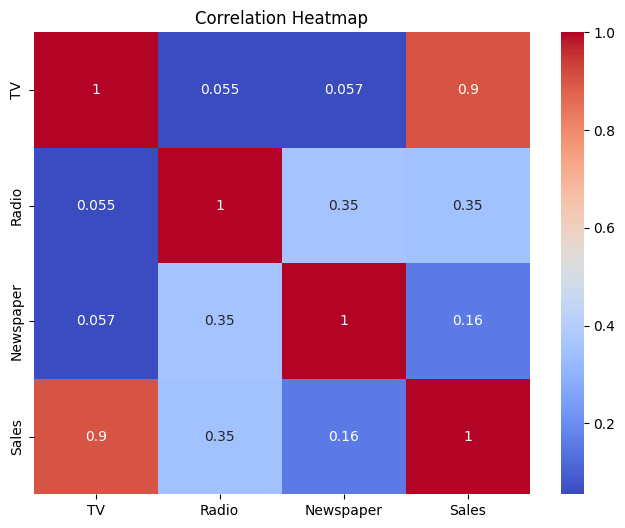

In [9]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [15]:
X = df[["TV", "Radio", "Newspaper"]]

y = df["Sales"]

In [16]:
X.head()
y.head()

0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (160, 3)
X_test: (40, 3)
y_train: (160,)
y_test: (40,)


In [36]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [37]:
model.fit(X_train, y_train)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [0.05450927 0.10094536 0.00433665]
Intercept: 4.714126402214127


In [39]:
y_pred = model.predict(X_test)
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

comparison.head(10)

,Actual Sales,Predicted Sales
0,16.9,17.034772
1,22.4,20.409740
2,21.4,23.723989
3,7.3,9.272785
4,24.7,21.682719
5,12.6,12.569402
6,22.3,21.081195
7,8.4,8.690350
8,16.5,17.237013
9,16.1,16.666575


In [40]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 1.2748262109549338


In [41]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 2.9077569102710896


In [43]:
import numpy as np

rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 1.7052146229349223


In [44]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.9059011844150826


In [45]:
print("Model Evaluation")
print("-----------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Model Evaluation
-----------------
MAE : 1.2748262109549338
MSE : 2.9077569102710896
RMSE: 1.7052146229349223
R²  : 0.9059011844150826


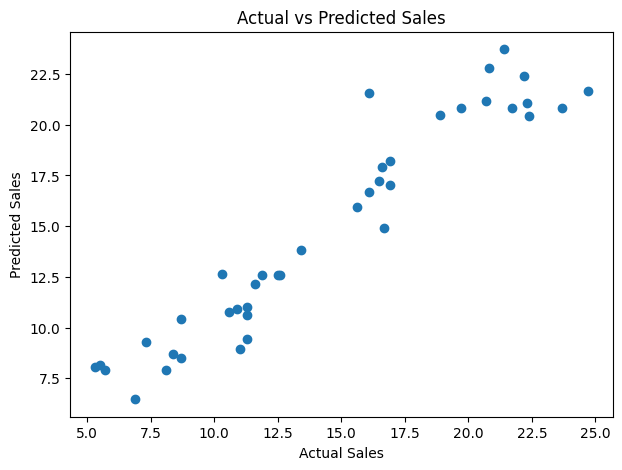

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [47]:
new_data = pd.DataFrame({
    "TV": [150],
    "Radio": [30],
    "Newspaper": [20]
})

predicted_sales = model.predict(new_data)

print("Predicted Sales:", predicted_sales[0])

Predicted Sales: 16.00561083602645


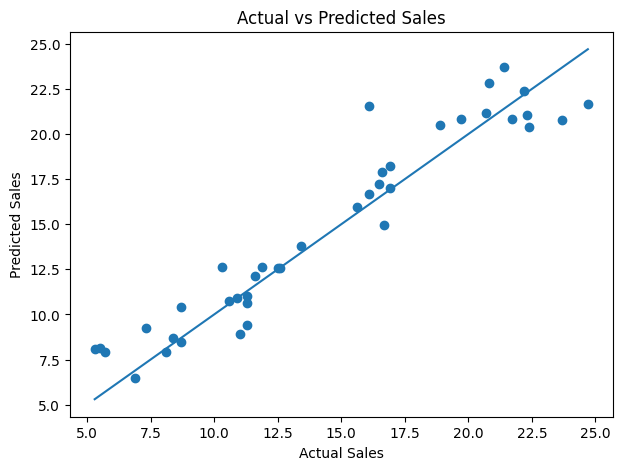

In [48]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred)

# Ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [49]:
print("Regression Equation:")
print(
    f"Sales = {model.intercept_:.2f} "
    f"+ ({model.coef_[0]:.2f} × TV) "
    f"+ ({model.coef_[1]:.2f} × Radio) "
    f"+ ({model.coef_[2]:.2f} × Newspaper)"
)

Regression Equation:
Sales = 4.71 + (0.05 × TV) + (0.10 × Radio) + (0.00 × Newspaper)


In [50]:
print("Project Completed Successfully!")
print("Model: Multiple Linear Regression")
print("Target: Sales")
print("Features: TV, Radio, Newspaper")
print("Evaluation: MAE, MSE, RMSE, R² Score")

Project Completed Successfully!
Model: Multiple Linear Regression
Target: Sales
Features: TV, Radio, Newspaper
Evaluation: MAE, MSE, RMSE, R² Score
